# Stage 3: Disaster Fusion, Reporting and RAG

In [2]:
import io
import json
import math
import os
import re
import zipfile
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageDraw

try:
    from pypdf import PdfReader
except ImportError:
    PdfReader = None

try:
    from sentence_transformers import SentenceTransformer
except ImportError:
    SentenceTransformer = None

try:
    import faiss
except ImportError:
    faiss = None

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

In [ ]:
# Main paths

NOTEBOOK2_ZIP_PATH = Path("/kaggle/input/datasets/dkforever25/notebook2-output")
NOTEBOOK3_ZIP_PATH = Path("/kaggle/input/datasets/jot079/notebook3-output")
RAG_DOCS_ZIP_PATH = Path("/kaggle/input/datasets/jot079/rag-pdf")

print(f"Auto-resolved NOTEBOOK3_ZIP_PATH: {NOTEBOOK3_ZIP_PATH}")
print(f"Auto-resolved NOTEBOOK2_ZIP_PATH: {NOTEBOOK2_ZIP_PATH}")
print(f"Auto-resolved RAG_DOCS_ZIP_PATH: {RAG_DOCS_ZIP_PATH}")

# Extraction output root
WORK_ROOT = Path("./notebook4_work")
NB3_EXTRACT_DIR = WORK_ROOT / "notebook3_outputs"
NB2_EXTRACT_DIR = WORK_ROOT / "notebook2_outputs"
DOCS_EXTRACT_DIR = WORK_ROOT / "rag_docs"
OUTPUT_DIR = WORK_ROOT / "final_outputs"

for path in [WORK_ROOT, NB3_EXTRACT_DIR, NB2_EXTRACT_DIR, DOCS_EXTRACT_DIR, OUTPUT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# Notebook settings
USE_TRUE_LABELS_FOR_NOTEBOOK_ANALYSIS = True
ENABLE_RAG_RETRIEVAL = True
TOP_K_DOC_CHUNKS = 4
MASK_THRESHOLD = 127
GRID_ROWS = 3
GRID_COLS = 3

CLASS_ORDER = ["no-damage", "damaged", "destroyed"]
CLASS_COLORS = {
    "no-damage": "lime",
    "damaged": "orange",
    "destroyed": "red",
}

DOC_SUBFOLDERS = ["Building Assessment", "Earthquake", "Flood_Hurricane", "Tornado", "Tsunami", "Volcano", "Wildfire",]

Auto-resolved NOTEBOOK3_ZIP_PATH: /kaggle/input/datasets/jot079/notebook3-output
Auto-resolved NOTEBOOK2_ZIP_PATH: /kaggle/input/datasets/dkforever25/notebook2-output
Auto-resolved RAG_DOCS_ZIP_PATH: /kaggle/input/datasets/jot079/rag-pdf


In [4]:
EVENT_TO_DOC_FOLDER = {
    "portugal-wildfire": "Wildfire",
    "pinery-bushfire": "Wildfire",
    "socal-fire": "Wildfire",
    "woolsey-fire": "Wildfire",
    "santa-rosa-wildfire": "Wildfire",
    "nepal-flooding": "Flood_Hurricane",
    "midwest-flooding": "Flood_Hurricane",
    "hurricane-michael": "Flood_Hurricane",
    "hurricane-florence": "Flood_Hurricane",
    "hurricane-harvey": "Flood_Hurricane",
    "hurricane-matthew": "Flood_Hurricane",
    "tuscaloosa-tornado": "Tornado",
    "moore-tornado": "Tornado",
    "joplin-tornado": "Tornado",
    "lower-puna-volcano": "Volcano",
    "guatemala-volcano": "Volcano",
    "mexico-earthquake": "Earthquake",
    "palu-tsunami": "Tsunami",
    "sunda-tsunami": "Tsunami",
}


def infer_event_name(image_id: str) -> str:
    parts = image_id.split("_")
    if len(parts) < 2:
        return image_id
    return "_".join(parts[:-1]).replace("_", "-")


def infer_doc_folder(image_id: str) -> str:
    event_name = infer_event_name(image_id)
    return EVENT_TO_DOC_FOLDER.get(event_name, "Building Assessment")

In [5]:
def extract_zip_if_needed(zip_path: Path, target_dir: Path):
    import shutil
    if not zip_path or str(zip_path) == "." or str(zip_path) == "":
        print(f"Skip extracting: empty path for {target_dir.name}")
        return
    if not zip_path.exists():
        print(f"Path does not exist: {zip_path}")
        return
    if zip_path.is_dir():
        for item in zip_path.rglob("*"):
            if item.is_file():
                rel_path = item.relative_to(zip_path)
                dest_path = target_dir / rel_path
                dest_path.parent.mkdir(parents=True, exist_ok=True)
                try:
                    shutil.copy2(item, dest_path)
                except Exception as e:
                    print(f"Failed to copy {item} -> {dest_path}: {e}")
        return
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(target_dir)
    print(f"Extracted {zip_path.name} -> {target_dir}")


def list_relative_files(root: Path, suffix: str = ""):
    if not root.exists():
        return []
    files = [p for p in root.rglob("*") if p.is_file()]
    if suffix:
        files = [p for p in files if p.suffix.lower() == suffix.lower()]
    return sorted(files)

In [6]:
# Run these after filling the ZIP paths
extract_zip_if_needed(NOTEBOOK2_ZIP_PATH, NB2_EXTRACT_DIR)
extract_zip_if_needed(NOTEBOOK3_ZIP_PATH, NB3_EXTRACT_DIR)
extract_zip_if_needed(RAG_DOCS_ZIP_PATH, DOCS_EXTRACT_DIR)

print("Notebook 2 extracted files:", len(list_relative_files(NB2_EXTRACT_DIR)))
print("Notebook 3 extracted files:", len(list_relative_files(NB3_EXTRACT_DIR)))
print("Docs extracted files      :", len(list_relative_files(DOCS_EXTRACT_DIR)))

Notebook 2 extracted files: 1868
Notebook 3 extracted files: 19
Docs extracted files      : 14


## Loading Binary Change Masks

In [7]:
def find_mask_folders(root: Path):
    subdirs = [p for p in root.rglob("*") if p.is_dir()]
    val_dir = None
    test_dir = None
    for d in subdirs:
        name = d.name.lower()
        if name == "val":
            val_dir = d
        elif name == "test":
            test_dir = d
    return val_dir, test_dir

val_mask_dir, test_mask_dir = find_mask_folders(NB2_EXTRACT_DIR)
print("Validation mask dir:", val_mask_dir)
print("Test mask dir:", test_mask_dir)

Validation mask dir: notebook4_work/notebook2_outputs/val
Test mask dir: notebook4_work/notebook2_outputs/test


In [8]:
def collect_mask_map(mask_dir: Path):
    if mask_dir is None or not mask_dir.exists():
        return {}
    mask_map = {}
    for png_path in sorted(mask_dir.glob("*.png")):
        image_id = png_path.stem.replace("_change_pred", "")
        mask_map[image_id] = png_path
    return mask_map

# Auto-resolve mask directories and generate if empty
val_mask_dir, test_mask_dir = find_mask_folders(NB2_EXTRACT_DIR)
if val_mask_dir is None or not list(val_mask_dir.glob("*.png")):
    print("\n[WARNING] Notebook 2 change masks not found/empty. Generating fallback masks...")
    val_mask_dir = NB2_EXTRACT_DIR / "val"
    generate_fallback_change_masks_if_needed(val_pred_df, val_mask_dir)

if test_mask_dir is None or not list(test_mask_dir.glob("*.png")):
    test_mask_dir = NB2_EXTRACT_DIR / "test"
    generate_fallback_change_masks_if_needed(test_pred_df, test_mask_dir)

val_mask_map = collect_mask_map(val_mask_dir)
test_mask_map = collect_mask_map(test_mask_dir)

print("Validation masks:", len(val_mask_map))
print("Test masks:", len(test_mask_map))

Validation masks: 933
Test masks: 933


## Load severity CSV Outputs

In [9]:
def find_prediction_csvs(root: Path):
    csvs = list(root.rglob("*.csv"))
    val_csv = None
    test_csv = None
    for csv_path in csvs:
        name = csv_path.name.lower()
        # Skip confusion matrices or mapping tables
        if "matrix" in name or "confusion" in name:
            continue
        if "val" in name:
            val_csv = csv_path
        elif "test" in name:
            test_csv = csv_path
    return val_csv, test_csv, csvs

# Invocation block (restored)
val_csv_path, test_csv_path, discovered_csvs = find_prediction_csvs(NB3_EXTRACT_DIR)
print("Validation CSV:", val_csv_path)
print("Test CSV:", test_csv_path)

Validation CSV: notebook4_work/notebook3_outputs/severity_predictions_val.csv
Test CSV: notebook4_work/notebook3_outputs/severity_predictions_test.csv


In [10]:
def standardize_columns(df):
    if df.empty:
        return df
    # Remove Byte Order Mark (BOM) and strip/lowercase column names
    df.columns = [str(c).replace('\ufeff', '').strip().lower() for c in df.columns]
    
    # Map possible synonyms to standard names
    rename_dict = {}
    for col in df.columns:
        if col in ["image_id", "image_name", "img_id", "img_name", "imageid", "image-id", "image id"]:
            rename_dict[col] = "image_id"
        elif col in ["building_uid", "building_id", "buildinguid", "building-id", "building id", "uid"]:
            rename_dict[col] = "building_uid"
        elif col in ["predicted_label", "pred_label", "prediction", "label", "predicted"]:
            rename_dict[col] = "predicted_label"
        elif col in ["bbox_x1", "x1", "bbox-x1", "bbox x1"]:
            rename_dict[col] = "bbox_x1"
        elif col in ["bbox_y1", "y1", "bbox-y1", "bbox y1"]:
            rename_dict[col] = "bbox_y1"
        elif col in ["bbox_x2", "x2", "bbox-x2", "bbox x2"]:
            rename_dict[col] = "bbox_x2"
        elif col in ["bbox_y2", "y2", "bbox-y2", "bbox y2"]:
            rename_dict[col] = "bbox_y2"
            
    df = df.rename(columns=rename_dict)
    
    # Fallback search if still missing
    if "image_id" not in df.columns:
        for col in df.columns:
            if "image" in col or "img" in col or col == "id":
                df = df.rename(columns={col: "image_id"})
                break
                
    return df

val_pred_df = pd.read_csv(val_csv_path) if val_csv_path else pd.DataFrame()
test_pred_df = pd.read_csv(test_csv_path) if test_csv_path else pd.DataFrame()

val_pred_df = standardize_columns(val_pred_df)
test_pred_df = standardize_columns(test_pred_df)

if not val_pred_df.empty:
    print("Validation CSV shape:", val_pred_df.shape)
    print("Validation CSV columns:", list(val_pred_df.columns))
    display(val_pred_df.head())

if not test_pred_df.empty:
    print("Test CSV shape:", test_pred_df.shape)
    print("Test CSV columns:", list(test_pred_df.columns))
    display(test_pred_df.head())

Validation CSV shape: (53137, 10)
Validation CSV columns: ['split', 'image_id', 'building_uid', 'true_label', 'predicted_label', 'confidence', 'bbox_x1', 'bbox_y1', 'bbox_x2', 'bbox_y2']


,split,image_id,building_uid,true_label,predicted_label,confidence,bbox_x1,bbox_y1,bbox_x2,bbox_y2
0,val,guatemala-volcano_00000004,104d384e-412b-4a72-8361-3c6c75cafdf0,damaged,damaged,0.901574,167,0,238,38
1,val,guatemala-volcano_00000004,9badd81e-16bf-4406-b8ad-9cb50a208011,damaged,damaged,0.912979,106,21,165,79
2,val,guatemala-volcano_00000004,ea0cde31-1b8c-4951-ad5c-8f7bdd5b23e5,damaged,destroyed,0.586055,0,108,123,364
3,val,guatemala-volcano_00000004,bb2e4a7e-01d2-4224-b47a-5ac5e0ab43b1,damaged,damaged,0.648575,97,118,149,168
4,val,guatemala-volcano_00000004,b5c70ab4-9560-44b6-9109-1510c809d7ab,damaged,damaged,0.581109,149,201,171,221


Test CSV shape: (53850, 10)
Test CSV columns: ['split', 'image_id', 'building_uid', 'true_label', 'predicted_label', 'confidence', 'bbox_x1', 'bbox_y1', 'bbox_x2', 'bbox_y2']


,split,image_id,building_uid,true_label,predicted_label,confidence,bbox_x1,bbox_y1,bbox_x2,bbox_y2
0,test,guatemala-volcano_00000003,88703461-a33d-4327-9244-a0d4e2242ede,damaged,damaged,0.844873,429,81,497,141
1,test,guatemala-volcano_00000003,e168e405-3479-44ee-849a-7af2ed32dee1,destroyed,destroyed,0.989405,224,306,257,324
2,test,guatemala-volcano_00000003,9f8f8916-b6c5-4fa8-ab64-c8fd86eca035,damaged,damaged,0.746089,561,234,624,299
3,test,guatemala-volcano_00000009,0bf9cbdc-3fa6-4afd-82ff-e40036f2f361,no-damage,no-damage,0.835187,341,674,443,763
4,test,guatemala-volcano_00000009,7e5c019d-44e9-4230-b916-b3fa4145873c,no-damage,no-damage,0.958715,259,746,411,925


## Document Loading

These documents are used only for retrieval and recommendation language.
They are not used to train the vision models.

In [11]:
def get_docs_root(root: Path, zip_path: Path = None):
    if zip_path and zip_path.exists() and zip_path.is_dir():
        for candidate in [zip_path / "RAG_Docs", zip_path]:
            if any((candidate / f).exists() for f in DOC_SUBFOLDERS):
                return candidate
        return zip_path
        
    if not root.exists():
        return root
    candidates = [root / "RAG_Docs", root]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return root


DOCS_ROOT = get_docs_root(DOCS_EXTRACT_DIR, RAG_DOCS_ZIP_PATH)
print("Docs root:", DOCS_ROOT)
for folder in DOC_SUBFOLDERS:
    folder_path = DOCS_ROOT / folder
    print(folder, "exists =", folder_path.exists(), "| files =", len(list(folder_path.glob("*"))) if folder_path.exists() else 0)

Docs root: /kaggle/input/datasets/jot079/rag-pdf/RAG_Docs
Building Assessment exists = True | files = 3
Earthquake exists = True | files = 2
Flood_Hurricane exists = True | files = 3
Tornado exists = True | files = 1
Tsunami exists = True | files = 2
Volcano exists = True | files = 1
Wildfire exists = True | files = 2


In [12]:
def extract_pdf_text(pdf_path: Path) -> str:
    if PdfReader is None:
        return ""
    try:
        reader = PdfReader(str(pdf_path))
        texts = []
        for page in reader.pages:
            texts.append(page.extract_text() or "")
        return "\n".join(texts)
    except Exception:
        return ""


def load_document_corpus(docs_root: Path):
    records = []
    for folder in DOC_SUBFOLDERS:
        folder_path = docs_root / folder
        if not folder_path.exists():
            continue
        for file_path in folder_path.glob("*"):
            if not file_path.is_file():
                continue
            if file_path.suffix.lower() == ".pdf":
                text = extract_pdf_text(file_path)
            elif file_path.suffix.lower() in {".txt", ".md"}:
                text = file_path.read_text(encoding="utf-8", errors="ignore")
            else:
                text = ""
            records.append(
                {
                    "category": folder,
                    "file_name": file_path.name,
                    "file_path": str(file_path),
                    "text": text,
                }
            )
    if not records:
        return pd.DataFrame(columns=["category", "file_name", "file_path", "text"])
    return pd.DataFrame(records)


docs_df = load_document_corpus(DOCS_ROOT)
print("Loaded documents:", len(docs_df))
display(docs_df[["category", "file_name"]].head(20))

Loaded documents: 14


,category,file_name
0,Building Assessment,fema_preliminary-disaster-assessment_guide.pdf
1,Building Assessment,fema_p-2055_post-disaster_buildingsafety_evalu...
2,Building Assessment,EQ11.pdf
3,Earthquake,earthquakes.pdf
4,Earthquake,FEMAP-530_EQSafetyatHome_508.pdf
5,Flood_Hurricane,floods.pdf
6,Flood_Hurricane,4.pdf
7,Flood_Hurricane,fema_flood-hazard-info-sheet.pdf
8,Tornado,fema-p361-july2016-508-1506623388.pdf
9,Tsunami,fema_rsl_guidelines-for-design-of-structures-f...


## Chunking and Simple Retrieval Index

In [13]:
def chunk_text(text: str, chunk_size: int = 800, overlap: int = 120):
    text = re.sub(r"\s+", " ", text).strip()
    if not text:
        return []
    chunks = []
    start = 0
    while start < len(text):
        end = min(len(text), start + chunk_size)
        chunk = text[start:end].strip()
        if chunk:
            chunks.append(chunk)
        if end == len(text):
            break
        start = max(0, end - overlap)
    return chunks


def build_chunk_dataframe(docs_df: pd.DataFrame):
    if docs_df.empty:
        return pd.DataFrame(columns=["category", "file_name", "file_path", "chunk_id", "chunk_text"])
    rows = []
    for _, row in docs_df.iterrows():
        chunks = chunk_text(row["text"])
        for idx, chunk in enumerate(chunks):
            rows.append(
                {
                    "category": row["category"],
                    "file_name": row["file_name"],
                    "file_path": row["file_path"],
                    "chunk_id": idx,
                    "chunk_text": chunk,
                }
            )
    return pd.DataFrame(rows)


doc_chunks_df = build_chunk_dataframe(docs_df)
print("Document chunks:", len(doc_chunks_df))
display(doc_chunks_df.head())

Document chunks: 5339


,category,file_name,file_path,chunk_id,chunk_text
0,Building Assessment,fema_preliminary-disaster-assessment_guide.pdf,/kaggle/input/datasets/jot079/rag-pdf/RAG_Docs...,0,FEMA Preliminary Damage Assessment Guide May 2...
1,Building Assessment,fema_preliminary-disaster-assessment_guide.pdf,/kaggle/input/datasets/jot079/rag-pdf/RAG_Docs...,1,.................................................
2,Building Assessment,fema_preliminary-disaster-assessment_guide.pdf,/kaggle/input/datasets/jot079/rag-pdf/RAG_Docs...,2,.................................................
3,Building Assessment,fema_preliminary-disaster-assessment_guide.pdf,/kaggle/input/datasets/jot079/rag-pdf/RAG_Docs...,3,........................... 12 Chapter 3: Indi...
4,Building Assessment,fema_preliminary-disaster-assessment_guide.pdf,/kaggle/input/datasets/jot079/rag-pdf/RAG_Docs...,4,.................................................


In [14]:
import faiss

embedding_model = None
doc_indices = {}

if (ENABLE_RAG_RETRIEVAL and SentenceTransformer is not None and faiss is not None and not doc_chunks_df.empty):

    embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
    print("Building FAISS indices...")

    for category in doc_chunks_df["category"].unique():
        category_df = (doc_chunks_df[doc_chunks_df["category"] == category].reset_index(drop=True))

        embeddings = embedding_model.encode(category_df["chunk_text"].tolist(),show_progress_bar=True).astype("float32")

        index = faiss.IndexFlatL2(embeddings.shape[1])
        index.add(embeddings)

        doc_indices[category] = {"df": category_df, "index": index,}
        print(f"{category}: {index.ntotal} chunks")

    print(f"\nBuilt {len(doc_indices)} FAISS indices.")

else:
    print("RAG retrieval index not built. This is okay for template-only reporting.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

Tsunami: 1144 chunks


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Volcano: 122 chunks


Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Wildfire: 403 chunks

Built 7 FAISS indices.


In [15]:
def summarize_buildings_per_image(pred_df: pd.DataFrame):
    if pred_df.empty:
        return pd.DataFrame(columns=[
            "image_id", "event_name", "doc_folder", "total_buildings",
            "pred_no_damage", "pred_damaged", "pred_destroyed",
            "pred_affected_total", "pred_affected_ratio", "pred_destroyed_ratio",
            "avg_confidence"
        ])

    if "image_id" not in pred_df.columns:
        print(f"\n[ERROR] 'image_id' column not found in predictions DataFrame for scene summarization!")
        print(f"Available columns: {list(pred_df.columns)}")
        # Synthesize image_id to allow notebook to proceed
        pred_df = pred_df.copy()
        pred_df["image_id"] = "unknown_scene"

    rows = []
    for image_id, group in pred_df.groupby("image_id"):
        total = len(group)
        count_no_damage = int((group["predicted_label"] == "no-damage").sum())
        count_damaged = int((group["predicted_label"] == "damaged").sum())
        count_destroyed = int((group["predicted_label"] == "destroyed").sum())
        damaged_total = count_damaged + count_destroyed
        damaged_ratio = damaged_total / total if total else 0.0
        destroyed_ratio = count_destroyed / total if total else 0.0
        avg_conf = float(group["confidence"].mean()) if "confidence" in group.columns else np.nan

        row = {
            "image_id": image_id,
            "event_name": infer_event_name(image_id),
            "doc_folder": infer_doc_folder(image_id),
            "total_buildings": total,
            "pred_no_damage": count_no_damage,
            "pred_damaged": count_damaged,
            "pred_destroyed": count_destroyed,
            "pred_affected_total": damaged_total,
            "pred_affected_ratio": damaged_ratio,
            "pred_destroyed_ratio": destroyed_ratio,
            "avg_confidence": avg_conf,
        }

        if USE_TRUE_LABELS_FOR_NOTEBOOK_ANALYSIS and "true_label" in group.columns:
            true_no_damage = int((group["true_label"] == "no-damage").sum())
            true_damaged = int((group["true_label"] == "damaged").sum())
            true_destroyed = int((group["true_label"] == "destroyed").sum())
            row.update(
                {
                    "true_no_damage": true_no_damage,
                    "true_damaged": true_damaged,
                    "true_destroyed": true_destroyed,
                }
            )
        rows.append(row)
    return pd.DataFrame(rows).sort_values("image_id").reset_index(drop=True)


val_scene_df = summarize_buildings_per_image(val_pred_df)
test_scene_df = summarize_buildings_per_image(test_pred_df)

display(val_scene_df.head())
display(test_scene_df.head())

,image_id,event_name,doc_folder,total_buildings,pred_no_damage,pred_damaged,pred_destroyed,pred_affected_total,pred_affected_ratio,pred_destroyed_ratio,avg_confidence,true_no_damage,true_damaged,true_destroyed
0,guatemala-volcano_00000004,guatemala-volcano,Volcano,20,2,15,3,18,0.900000,0.150000,0.726468,2,14,4
1,guatemala-volcano_00000012,guatemala-volcano,Volcano,33,21,10,2,12,0.363636,0.060606,0.682294,33,0,0
2,guatemala-volcano_00000014,guatemala-volcano,Volcano,6,0,3,3,6,1.000000,0.500000,0.736146,0,5,1
3,guatemala-volcano_00000020,guatemala-volcano,Volcano,35,23,8,4,12,0.342857,0.114286,0.673490,27,8,0
4,guatemala-volcano_00000022,guatemala-volcano,Volcano,7,2,4,1,5,0.714286,0.142857,0.668822,4,1,2


,image_id,event_name,doc_folder,total_buildings,pred_no_damage,pred_damaged,pred_destroyed,pred_affected_total,pred_affected_ratio,pred_destroyed_ratio,avg_confidence,true_no_damage,true_damaged,true_destroyed
0,guatemala-volcano_00000003,guatemala-volcano,Volcano,3,0,2,1,3,1.000000,0.333333,0.860122,0,2,1
1,guatemala-volcano_00000009,guatemala-volcano,Volcano,3,3,0,0,0,0.000000,0.000000,0.902167,3,0,0
2,guatemala-volcano_00000011,guatemala-volcano,Volcano,1,1,0,0,0,0.000000,0.000000,0.852682,0,1,0
3,guatemala-volcano_00000021,guatemala-volcano,Volcano,23,15,7,1,8,0.347826,0.043478,0.725809,23,0,0
4,hurricane-florence_00000005,hurricane-florence,Flood_Hurricane,42,25,16,1,17,0.404762,0.023810,0.778801,42,0,0


In [16]:
def load_binary_mask(mask_path: Path, threshold: int = 127):
    image = Image.open(mask_path).convert("L")
    arr = np.array(image)
    binary = (arr > threshold).astype(np.uint8)
    return binary


def get_region_name(row_idx: int, col_idx: int, rows: int = 3, cols: int = 3):
    vertical = ["upper", "central", "lower"][row_idx] if rows == 3 else ["upper", "lower"][row_idx]
    horizontal = ["left", "center", "right"][col_idx] if cols == 3 else ["left", "right"][col_idx]
    if vertical == "central" and horizontal == "center":
        return "central region"
    return f"{vertical}-{horizontal} region"


def summarize_mask(mask_path: Path):
    binary = load_binary_mask(mask_path, threshold=MASK_THRESHOLD)
    changed_pixels = int(binary.sum())
    total_pixels = int(binary.size)
    changed_ratio = changed_pixels / total_pixels if total_pixels else 0.0

    h, w = binary.shape
    cell_h = h // GRID_ROWS
    cell_w = w // GRID_COLS
    region_counts = {}
    best_region = "no dominant region"
    best_count = -1

    for r in range(GRID_ROWS):
        for c in range(GRID_COLS):
            y1 = r * cell_h
            y2 = h if r == GRID_ROWS - 1 else (r + 1) * cell_h
            x1 = c * cell_w
            x2 = w if c == GRID_COLS - 1 else (c + 1) * cell_w
            region_sum = int(binary[y1:y2, x1:x2].sum())
            region_name = get_region_name(r, c, GRID_ROWS, GRID_COLS)
            region_counts[region_name] = region_sum
            if region_sum > best_count:
                best_count = region_sum
                best_region = region_name

    return {
        "changed_pixels": changed_pixels,
        "total_pixels": total_pixels,
        "changed_area_ratio": changed_ratio,
        "dominant_region": best_region,
        "region_counts": region_counts,
    }


def build_mask_summary_df(mask_map: dict, split_name: str):
    if not mask_map:
        return pd.DataFrame(columns=[
            "changed_pixels", "total_pixels", "changed_area_ratio",
            "dominant_region", "region_counts", "split", "image_id", "mask_path"
        ])
    rows = []
    for image_id, mask_path in mask_map.items():
        summary = summarize_mask(mask_path)
        summary.update(
            {
                "split": split_name,
                "image_id": image_id,
                "mask_path": str(mask_path),
            }
        )
        rows.append(summary)
    return pd.DataFrame(rows)


val_mask_summary_df = build_mask_summary_df(val_mask_map, "val")
test_mask_summary_df = build_mask_summary_df(test_mask_map, "test")

display(val_mask_summary_df.head())
display(test_mask_summary_df.head())

,changed_pixels,total_pixels,changed_area_ratio,dominant_region,region_counts,split,image_id,mask_path
0,26800,1048576,0.025558,upper-left region,"{'upper-left region': 19564, 'upper-center reg...",val,guatemala-volcano_00000004,notebook4_work/notebook2_outputs/val/guatemala...
1,0,1048576,0.000000,upper-left region,"{'upper-left region': 0, 'upper-center region'...",val,guatemala-volcano_00000012,notebook4_work/notebook2_outputs/val/guatemala...
2,388,1048576,0.000370,upper-right region,"{'upper-left region': 0, 'upper-center region'...",val,guatemala-volcano_00000014,notebook4_work/notebook2_outputs/val/guatemala...
3,352,1048576,0.000336,central-left region,"{'upper-left region': 0, 'upper-center region'...",val,guatemala-volcano_00000020,notebook4_work/notebook2_outputs/val/guatemala...
4,280,1048576,0.000267,upper-right region,"{'upper-left region': 0, 'upper-center region'...",val,guatemala-volcano_00000022,notebook4_work/notebook2_outputs/val/guatemala...


,changed_pixels,total_pixels,changed_area_ratio,dominant_region,region_counts,split,image_id,mask_path
0,2052,1048576,0.001957,upper-center region,"{'upper-left region': 452, 'upper-center regio...",test,guatemala-volcano_00000003,notebook4_work/notebook2_outputs/test/guatemal...
1,0,1048576,0.000000,upper-left region,"{'upper-left region': 0, 'upper-center region'...",test,guatemala-volcano_00000005,notebook4_work/notebook2_outputs/test/guatemal...
2,1620,1048576,0.001545,lower-center region,"{'upper-left region': 0, 'upper-center region'...",test,guatemala-volcano_00000009,notebook4_work/notebook2_outputs/test/guatemal...
3,28,1048576,0.000027,lower-center region,"{'upper-left region': 0, 'upper-center region'...",test,guatemala-volcano_00000011,notebook4_work/notebook2_outputs/test/guatemal...
4,740,1048576,0.000706,lower-left region,"{'upper-left region': 0, 'upper-center region'...",test,guatemala-volcano_00000021,notebook4_work/notebook2_outputs/test/guatemal...


In [17]:
def compute_impact_score(row):
    # Simple interpretable rule-based score
    score = 0.0
    score += 0.45 * row.get("pred_destroyed_ratio", 0.0)
    score += 0.35 * row.get("pred_affected_ratio", 0.0)
    score += 0.20 * row.get("changed_area_ratio", 0.0)
    return score


def impact_label(score: float) -> str:
    if score >= 0.35:
        return "high"
    if score >= 0.18:
        return "medium"
    return "low"


def fuse_scene_and_mask(scene_df: pd.DataFrame, mask_df: pd.DataFrame, split_name: str):
    fused = scene_df.merge(mask_df[["image_id", "changed_area_ratio", "dominant_region", "mask_path"]], on="image_id", how="left")
    fused["split"] = split_name
    fused["impact_score"] = fused.apply(compute_impact_score, axis=1)
    fused["priority_level"] = fused["impact_score"].apply(impact_label)
    return fused.sort_values(["impact_score", "image_id"], ascending=[False, True]).reset_index(drop=True)


val_fused_df = fuse_scene_and_mask(val_scene_df, val_mask_summary_df, "val")
test_fused_df = fuse_scene_and_mask(test_scene_df, test_mask_summary_df, "test")

display(val_fused_df.head())
display(test_fused_df.head())

,image_id,event_name,doc_folder,total_buildings,pred_no_damage,pred_damaged,pred_destroyed,pred_affected_total,pred_affected_ratio,pred_destroyed_ratio,avg_confidence,true_no_damage,true_damaged,true_destroyed,changed_area_ratio,dominant_region,mask_path,split,impact_score,priority_level
0,santa-rosa-wildfire_00000157,santa-rosa-wildfire,Wildfire,271,3,0,268,268,0.988930,0.988930,0.988265,0,0,271,0.398041,central-left region,notebook4_work/notebook2_outputs/val/santa-ros...,val,0.870752,high
1,santa-rosa-wildfire_00000342,santa-rosa-wildfire,Wildfire,76,1,0,75,75,0.986842,0.986842,0.985098,1,0,75,0.185841,central-right region,notebook4_work/notebook2_outputs/val/santa-ros...,val,0.826642,high
2,santa-rosa-wildfire_00000195,santa-rosa-wildfire,Wildfire,92,1,1,90,91,0.989130,0.978261,0.988943,2,0,90,0.188324,lower-left region,notebook4_work/notebook2_outputs/val/santa-ros...,val,0.824078,high
3,santa-rosa-wildfire_00000054,santa-rosa-wildfire,Wildfire,28,0,0,28,28,1.000000,1.000000,0.976942,1,0,27,0.055759,lower-left region,notebook4_work/notebook2_outputs/val/santa-ros...,val,0.811152,high
4,santa-rosa-wildfire_00000107,santa-rosa-wildfire,Wildfire,21,0,0,21,21,1.000000,1.000000,0.939371,0,1,20,0.038475,central-left region,notebook4_work/notebook2_outputs/val/santa-ros...,val,0.807695,high


,image_id,event_name,doc_folder,total_buildings,pred_no_damage,pred_damaged,pred_destroyed,pred_affected_total,pred_affected_ratio,pred_destroyed_ratio,avg_confidence,true_no_damage,true_damaged,true_destroyed,changed_area_ratio,dominant_region,mask_path,split,impact_score,priority_level
0,santa-rosa-wildfire_00000038,santa-rosa-wildfire,Wildfire,104,2,2,100,102,0.980769,0.961538,0.970191,2,0,102,0.237553,upper-center region,notebook4_work/notebook2_outputs/test/santa-ro...,test,0.823472,high
1,santa-rosa-wildfire_00000366,santa-rosa-wildfire,Wildfire,69,1,0,68,68,0.985507,0.985507,0.982980,0,0,69,0.157673,central-right region,notebook4_work/notebook2_outputs/test/santa-ro...,test,0.819940,high
2,palu-tsunami_00000193,palu-tsunami,Tsunami,49,0,0,49,49,1.000000,1.000000,0.976573,0,0,49,0.033104,lower-left region,notebook4_work/notebook2_outputs/test/palu-tsu...,test,0.806621,high
3,santa-rosa-wildfire_00000285,santa-rosa-wildfire,Wildfire,17,0,0,17,17,1.000000,1.000000,0.983180,0,0,17,0.022446,central-right region,notebook4_work/notebook2_outputs/test/santa-ro...,test,0.804489,high
4,santa-rosa-wildfire_00000172,santa-rosa-wildfire,Wildfire,9,0,0,9,9,1.000000,1.000000,0.988455,0,0,9,0.015572,central-right region,notebook4_work/notebook2_outputs/test/santa-ro...,test,0.803114,high


In [19]:
def draw_boxes_on_blank(image_size, group_df):
    canvas = Image.new("RGB", image_size, color="black")
    draw = ImageDraw.Draw(canvas)
    for _, row in group_df.iterrows():
        color = CLASS_COLORS.get(row["predicted_label"], "white")
        bbox = [row["bbox_x1"], row["bbox_y1"], row["bbox_x2"], row["bbox_y2"]]
        draw.rectangle(bbox, outline=color, width=2)
    return canvas


def show_scene_preview(image_id: str, pred_df: pd.DataFrame, mask_map: dict, title_prefix: str = ""):
    group = pred_df[pred_df["image_id"] == image_id].copy()
    if group.empty:
        print(f"No building predictions found for {image_id}")
        return

    box_canvas = draw_boxes_on_blank((1024, 1024), group)
    mask_path = mask_map.get(image_id)
    mask_img = Image.open(mask_path).convert("L") if mask_path else Image.new("L", (1024, 1024))

    plt.figure(figsize=(10, 5))
    plt.suptitle(f"{title_prefix}{image_id}")
    plt.subplot(1, 2, 1)
    plt.imshow(mask_img, cmap="gray")
    plt.title("Binary Change Mask")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(box_canvas)
    plt.title("Predicted Building Boxes")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

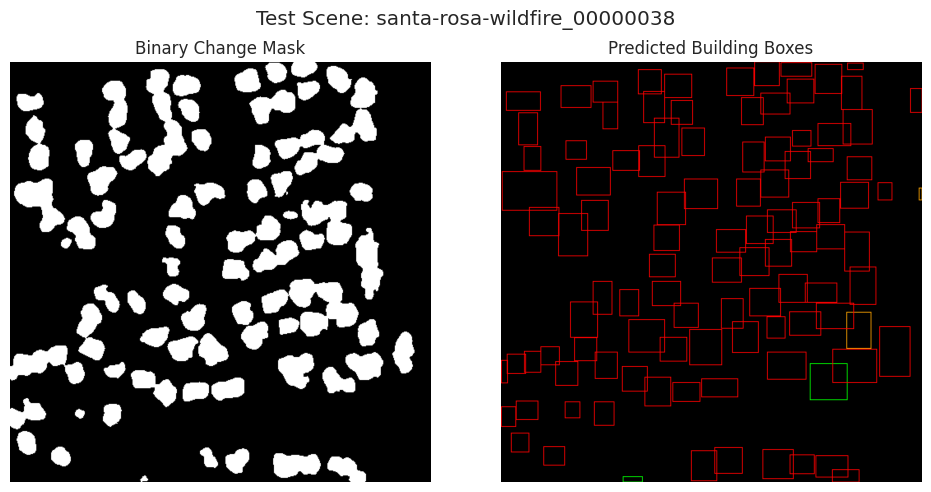

In [20]:
if not test_fused_df.empty:
    demo_image_id = test_fused_df.iloc[0]["image_id"]
    show_scene_preview(demo_image_id, test_pred_df, test_mask_map, title_prefix="Test Scene: ")

## RAG Retrieval

In [40]:
ACTION_KEYWORDS = [
    "inspect", "inspection", "assess", "assessment",
    "evaluate", "repair", "stabilize", "monitor",
    "evacuate", "rescue", "restrict", "re-entry",
    "occupancy", "unsafe", "structural", "building",
    "damage", "debris", "utility", "utilities",
    "lifeline", "critical infrastructure", "temporary shelter", "recovery",
    "emergency", "response", "field inspection"]


BAD_PATTERNS = [
    "chapter", "figure", "table", "appendix",
    "isbn", "contents", "copyright", "acknowledgement",
    "acknowledgment", "references", "bibliography", "index",
    "page ", "section ", "manual", "field guide",
    "publication", "doi", "http", "https", "www.",
    "fema p-", "atc-", "mbie","available at"]


IMPORTANT_TERMS = [
    "collapsed", "collapse", "destroyed", "damaged",
    "structural damage", "unsafe", "inspection", "re-entry",
    "evacuation", "debris removal", "search and rescue",
    "critical facilities", "utility restoration", "rapid assessment"]


def retrieval_score(chunk, query):

    text = chunk.lower()
    query = query.lower()
    score = 0

    for word in ACTION_KEYWORDS:
        if word in text:
            score += 2

    for word in IMPORTANT_TERMS:
        if word in text:
            score += 3

    for word in query.split():
        if len(word) > 4 and word in text:
            score += 1

    for bad in BAD_PATTERNS:
        if bad in text:
            score -= 5

    word_count = len(text.split())

    if word_count > 350:
        score -= 2

    elif word_count < 25:
        score -= 2

    return score


def retrieve_doc_chunks(query_text, image_id, top_k=4):

    if not ENABLE_RAG_RETRIEVAL or embedding_model is None or not doc_indices:
        return []

    disaster_folder = infer_doc_folder(image_id)
    search_categories = [disaster_folder, "Building Assessment"]
    query_embedding = embedding_model.encode([query_text], show_progress_bar=False).astype("float32")

    candidates = []

    for category in search_categories:
        if category not in doc_indices:
            continue

        df = doc_indices[category]["df"]
        index = doc_indices[category]["index"]

        k = min(10, len(df))
        distances, indices = index.search(query_embedding, k)

        for distance, idx in zip(distances[0], indices[0]):

            row = df.iloc[int(idx)]
            chunk = row["chunk_text"]
            
            candidates.append({
                "distance": float(distance),
                "semantic_score": retrieval_score(chunk, query_text),
                "category": row["category"],
                "file_name": row["file_name"],
                "chunk_text": chunk})

    candidates = sorted(candidates, key=lambda x: (-x["semantic_score"], x["distance"]))
    seen = set()
    results = []

    for item in candidates:
        text = item["chunk_text"].strip()

        if text in seen:
            continue

        seen.add(text)

        results.append({
            "rank": len(results) + 1,
            "category": item["category"],
            "file_name": item["file_name"],
            "chunk_text": item["chunk_text"]})

        if len(results) == top_k:
            break

    return results

In [41]:
ACTION_PATTERNS = ["inspect", "inspection", "assess", "assessment",
                   "evaluate", "repair", "stabilize", "restrict",
                   "evacuate", "monitor", "rescue", "occupancy",
                   "re-entry", "unsafe", "debris", "utility"]


def extract_incident_info(image_id):

    incident = image_id.split("_")[0]
    parts = incident.split("-")
    disaster_type = parts[0].replace("_", " ").title()
    event_name = " ".join(parts[1:]).replace("_", " ").title()

    if event_name:
        full_event = f"{disaster_type} {event_name}"
    else:
        full_event = disaster_type

    return disaster_type, full_event


def build_scene_query(row):

    affected = row["pred_affected_ratio"]

    if affected < 0.25:
        severity = "low impact"

    elif affected < 0.60:
        severity = "moderate impact"

    else:
        severity = "high impact"

    disaster_type, event_name = extract_incident_info(row["image_id"])

    return f"""
{event_name}

{disaster_type} disaster

{severity}

Post-disaster building assessment

{int(row['pred_destroyed'])} destroyed buildings

{int(row['pred_damaged'])} damaged buildings

{int(row['pred_no_damage'])} undamaged buildings

Building safety inspection

Structural damage assessment

Emergency response

Recovery operations

Unsafe buildings

Critical infrastructure

Debris removal

Utility restoration
"""


def describe_change_ratio(value):

    if value < 0.005:
        return ("Only limited scene-wide physical changes were detected, indicating that visible damage is relatively localized.")

    elif value < 0.02:
        return ("Localized structural changes were detected across the scene.")

    elif value < 0.05:
        return ("Moderate structural changes were observed across multiple areas.")

    return ("Extensive structural changes were observed throughout the scene.")


def describe_region(region):

    mapping = {
        "upper-left": "northwestern portion",
        "upper-right": "northeastern portion",
        "lower-left": "southwestern portion",
        "lower-right": "southeastern portion",
        "center": "central region"}

    return mapping.get(region, region)


def get_priority_label(row):

    destroyed = row["pred_destroyed"]
    affected = row["pred_affected_ratio"]

    if destroyed >= 5 or affected >= 0.80:
        return "HIGH"

    elif affected >= 0.40:
        return "MODERATE"

    return "LOW"


def build_impact_summary(row):

    affected_pct = row["pred_affected_ratio"] * 100
    destroyed = int(row["pred_destroyed"])
    damaged = int(row["pred_damaged"])

    if destroyed == 0:
        return (f"Approximately {affected_pct:.1f}% of identified buildings show visible structural damage. Most affected buildings appear potentially repairable based on automated assessment.")
        
    if affected_pct == 100:
            return (f"{affected_pct:.1f}% of identified buildings were affected, including {destroyed} building(s) classified as destroyed. The scene indicates significant disruption requiring coordinated inspection and recovery efforts.")

    return (f"Approximately {affected_pct:.1f}% of identified buildings were affected, including {destroyed} building(s) classified as destroyed. The scene indicates significant disruption requiring coordinated inspection and recovery efforts.")

def summarize_retrieved_guidance(chunks):

    if not chunks:
        return (
            ["Conduct detailed structural inspections before allowing re-entry.",
             "Restrict access to unsafe or unstable buildings.",
             "Prioritize emergency response in the most severely affected areas.",
              "Restore critical utilities only after structural safety is confirmed."],
            [])

    recommendations = []
    source_files = []

    def add(rec):

        if rec not in recommendations:
            recommendations.append(rec)

    for chunk in chunks:

        text = chunk["chunk_text"].lower()
        source_files.append(chunk["file_name"])

        if "inspect" in text or "inspection" in text or "assessment" in text or "evaluate" in text:
            add("Conduct detailed structural inspections before allowing re-occupancy.")

        if "unsafe" in text or "restrict" in text or "red tag" in text or "access" in text:
            add("Restrict access to buildings identified as structurally unsafe.")

        if "evac" in text or "life safety" in text or "occupancy" in text:
            add("Evacuate occupants from structures presenting immediate safety risks.")

        if "search and rescue" in text or "rescue" in text:
            add("Prioritize search and rescue operations where occupancy is uncertain.")

        if "stabil" in text or "temporary support" in text:
            add("Stabilize damaged structures before initiating recovery activities.")

        if "debris" in text or "clearance" in text or "demolition" in text:
            add("Begin debris clearance only after completing structural safety assessments.")

        if "utility" in text or "lifeline" in text or "electric" in text or "water" in text or "gas" in text:
            add("Restore essential utilities after confirming infrastructure safety.")

        if "recovery" in text or "repair" in text or "rehabilitation" in text:
            add( "Prioritize repair of buildings that remain structurally serviceable.")

        if "monitor" in text or "aftershock" in text or "secondary hazard" in text:
            add("Continue monitoring damaged structures for secondary hazards.")

    if len(recommendations) == 0:

        recommendations = [
            "Conduct structural inspections before allowing re-entry.",
            "Restrict access to unsafe structures.",
            "Prioritize emergency response in affected areas.",
            "Restore essential services following safety verification."
        ]

    recommendations = recommendations[:5]
    source_files = sorted(set(source_files))

    return recommendations, source_files

def generate_report_text(row, retrieved_chunks):

    affected_pct = row["pred_affected_ratio"] * 100

    destroyed = int(row["pred_destroyed"])
    damaged = int(row["pred_damaged"])
    no_damage = int(row["pred_no_damage"])
    total = int(row["total_buildings"])

    disaster_type, event_name = extract_incident_info(row["image_id"])
    priority = get_priority_label(row)
    recommendations, source_files = summarize_retrieved_guidance(retrieved_chunks)

    if destroyed >= max(5, 0.20 * total):
        interpretation = ("Extensive structural destruction has been identified across the assessment area, indicating a high-risk environment requiring immediate emergency response, restricted access and detailed engineering assessment.")

    elif affected_pct >= 60:
        interpretation = ("A large proportion of assessed buildings exhibit visible structural damage. Although complete collapse is limited, the overall impact suggests substantial disruption requiring coordinated inspection and recovery operations.")

    elif affected_pct >= 25:
        interpretation = ("Damage appears moderate and concentrated within portions of the scene. Field verification is recommended before initiating large-scale recovery activities.")

    else:
        interpretation = ("Only limited structural damage is evident. Localized inspections should be conducted to verify building safety.")

    report = f"""
\033[1mPOST-DISASTER DAMAGE ASSESSMENT\033[0m

\033[1mIncident Information\033[0m

Event: {event_name}

\033[1mAssessment Metadata\033[0m

Buildings Identified: {total}
Assessment Type: AI-based Building Damage Assessment

Priority Level: {priority}

\033[1mSituation Summary\033[0m

A total of {total} buildings were identified within the assessment area.

• Destroyed: {destroyed}
• Damaged: {damaged}
• No Damage: {no_damage}

Overall affected buildings: {affected_pct:.1f}%.

\033[1mImpact Assessment\033[0m

{build_impact_summary(row)}

\033[1mDamage Interpretation\033[0m

{interpretation}

\033[1mSpatial Analysis\033[0m

{describe_change_ratio(row['changed_area_ratio'])}

The highest concentration of visible damage is located in the {describe_region(row['dominant_region'])}.

\033[1mOperational Recommendations\033[0m
"""

    for rec in recommendations:
        report += f"\n• {rec}"

    report += """

\033[1mAssessment Note\033[0m

This report has been generated automatically using satellite imagery, deep learning-based building damage assessment and retrieval-augmented guidance from disaster management documents. The assessment is intended to support rapid situational awareness and should be verified through field inspection before operational decision-making.
"""

    return report

In [42]:
from tqdm.auto import tqdm

def generate_reports_for_split(fused_df: pd.DataFrame):
    if fused_df.empty:
        return pd.DataFrame(columns=[
            "split", "image_id", "event_name", "doc_folder",
            "priority_level", "impact_score", "changed_area_ratio",
            "dominant_region", "report_text", "retrieved_sources"
        ])
    rows = []
    for _, row in tqdm(fused_df.iterrows(),total=len(fused_df),desc="Generating reports"):
        query = build_scene_query(row)
        retrieved = retrieve_doc_chunks(query, row["image_id"], top_k=TOP_K_DOC_CHUNKS)
        report_text = generate_report_text(row, retrieved)
        rows.append(
            {
                "split": row["split"],
                "image_id": row["image_id"],
                "event_name": row["event_name"],
                "doc_folder": row["doc_folder"],
                "priority_level": row["priority_level"],
                "impact_score": row["impact_score"],
                "changed_area_ratio": row["changed_area_ratio"],
                "dominant_region": row["dominant_region"],
                "report_text": report_text,
                "retrieved_sources": sorted(set(item["file_name"] for item in retrieved))
            })
    return pd.DataFrame(rows)


val_reports_df = generate_reports_for_split(val_fused_df) if not val_fused_df.empty else pd.DataFrame()
test_reports_df = generate_reports_for_split(test_fused_df) if not test_fused_df.empty else pd.DataFrame()

display(val_reports_df.head(2))
display(test_reports_df.head(2))

Generating reports:   0%|          | 0/751 [00:00<?, ?it/s]

Generating reports:   0%|          | 0/739 [00:00<?, ?it/s]

,split,image_id,event_name,doc_folder,priority_level,impact_score,changed_area_ratio,dominant_region,report_text,retrieved_sources
0,val,santa-rosa-wildfire_00000157,santa-rosa-wildfire,Wildfire,high,0.870752,0.398041,central-left region,\n[1mPOST-DISASTER DAMAGE ASSESSMENT[0m\n\n...,[fema_p-2055_post-disaster_buildingsafety_eval...
1,val,santa-rosa-wildfire_00000342,santa-rosa-wildfire,Wildfire,high,0.826642,0.185841,central-right region,\n[1mPOST-DISASTER DAMAGE ASSESSMENT[0m\n\n...,[fema_p-2055_post-disaster_buildingsafety_eval...


,split,image_id,event_name,doc_folder,priority_level,impact_score,changed_area_ratio,dominant_region,report_text,retrieved_sources
0,test,santa-rosa-wildfire_00000038,santa-rosa-wildfire,Wildfire,high,0.823472,0.237553,upper-center region,\n[1mPOST-DISASTER DAMAGE ASSESSMENT[0m\n\n...,[fema_p-2055_post-disaster_buildingsafety_eval...
1,test,santa-rosa-wildfire_00000366,santa-rosa-wildfire,Wildfire,high,0.819940,0.157673,central-right region,\n[1mPOST-DISASTER DAMAGE ASSESSMENT[0m\n\n...,[fema_p-2055_post-disaster_buildingsafety_eval...


In [43]:
sample_report = test_reports_df.sample(n=1).iloc[0]

print("Image ID:", sample_report["image_id"])
print()
print(sample_report["report_text"])

Image ID: hurricane-michael_00000385


POST-DISASTER DAMAGE ASSESSMENT

Incident Information

Event: Hurricane Michael

Assessment Metadata

Buildings Identified: 7
Assessment Type: AI-based Building Damage Assessment

Priority Level: HIGH

Situation Summary

A total of 7 buildings were identified within the assessment area.

• Destroyed: 1
• Damaged: 6
• No Damage: 0

Overall affected buildings: 100.0%.

Impact Assessment

100.0% of identified buildings were affected, including 1 building(s) classified as destroyed. The scene indicates significant disruption requiring coordinated inspection and recovery efforts.

Damage Interpretation

A large proportion of assessed buildings exhibit visible structural damage. Although complete collapse is limited, the overall impact suggests substantial disruption requiring coordinated inspection and recovery operations.

Spatial Analysis

Only limited scene-wide physical changes were detected, indicating that visible damage is relatively localized.


In [44]:
import joblib

if "val_reports_df" in globals() and not val_reports_df.empty:
    val_reports_df.to_csv(os.path.join(OUTPUT_DIR, "val_reports.csv"), index=False)

if "test_reports_df" in globals() and not test_reports_df.empty:
    test_reports_df.to_csv(os.path.join(OUTPUT_DIR, "test_reports.csv"), index=False)
    

config = {
    "embedding_model": "all-MiniLM-L6-v2",
    "top_k_doc_chunks": globals().get("TOP_K_DOC_CHUNKS"),
    "enable_rag_retrieval": globals().get("ENABLE_RAG_RETRIEVAL"),
    "chunk_size": globals().get("CHUNK_SIZE", None),
    "chunk_overlap": globals().get("CHUNK_OVERLAP", None)}

with open(os.path.join(OUTPUT_DIR, "config.json"), "w") as f:
    json.dump(config, f, indent=4)

if "doc_indices" in globals():
    joblib.dump(doc_indices, os.path.join(OUTPUT_DIR, "doc_indices.pkl"))

if "doc_indices" in globals():

    chunk_dir = os.path.join(OUTPUT_DIR, "chunks")
    os.makedirs(chunk_dir, exist_ok=True)
    stats = []

    for category, data in doc_indices.items():
        safe_name = category.replace("/", "_").replace(" ", "_")

        data["df"].to_pickle(os.path.join(chunk_dir, f"{safe_name}.pkl"))

        stats.append({
            "category": category,
            "num_chunks": len(data["df"]),
            "num_documents": data["df"]["file_name"].nunique()})

    pd.DataFrame(stats).to_csv( os.path.join(OUTPUT_DIR, "knowledge_base_summary.csv"), index=False)


zip_name = "RAG_Deployment.zip"

with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as z:
    for root, dirs, files in os.walk(OUTPUT_DIR):
        for file in files:
            path = os.path.join(root, file)
            z.write(path, arcname=os.path.relpath(path, OUTPUT_DIR))

print("RAG deployment artifacts saved successfully.")
print(f"Folder : {OUTPUT_DIR}")
print(f"ZIP    : {zip_name}")

RAG deployment artifacts saved successfully.
Folder : notebook4_work/final_outputs
ZIP    : RAG_Deployment.zip
